Dataset URL: https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset
License(s): CC0-1.0

Detected outliers: 19


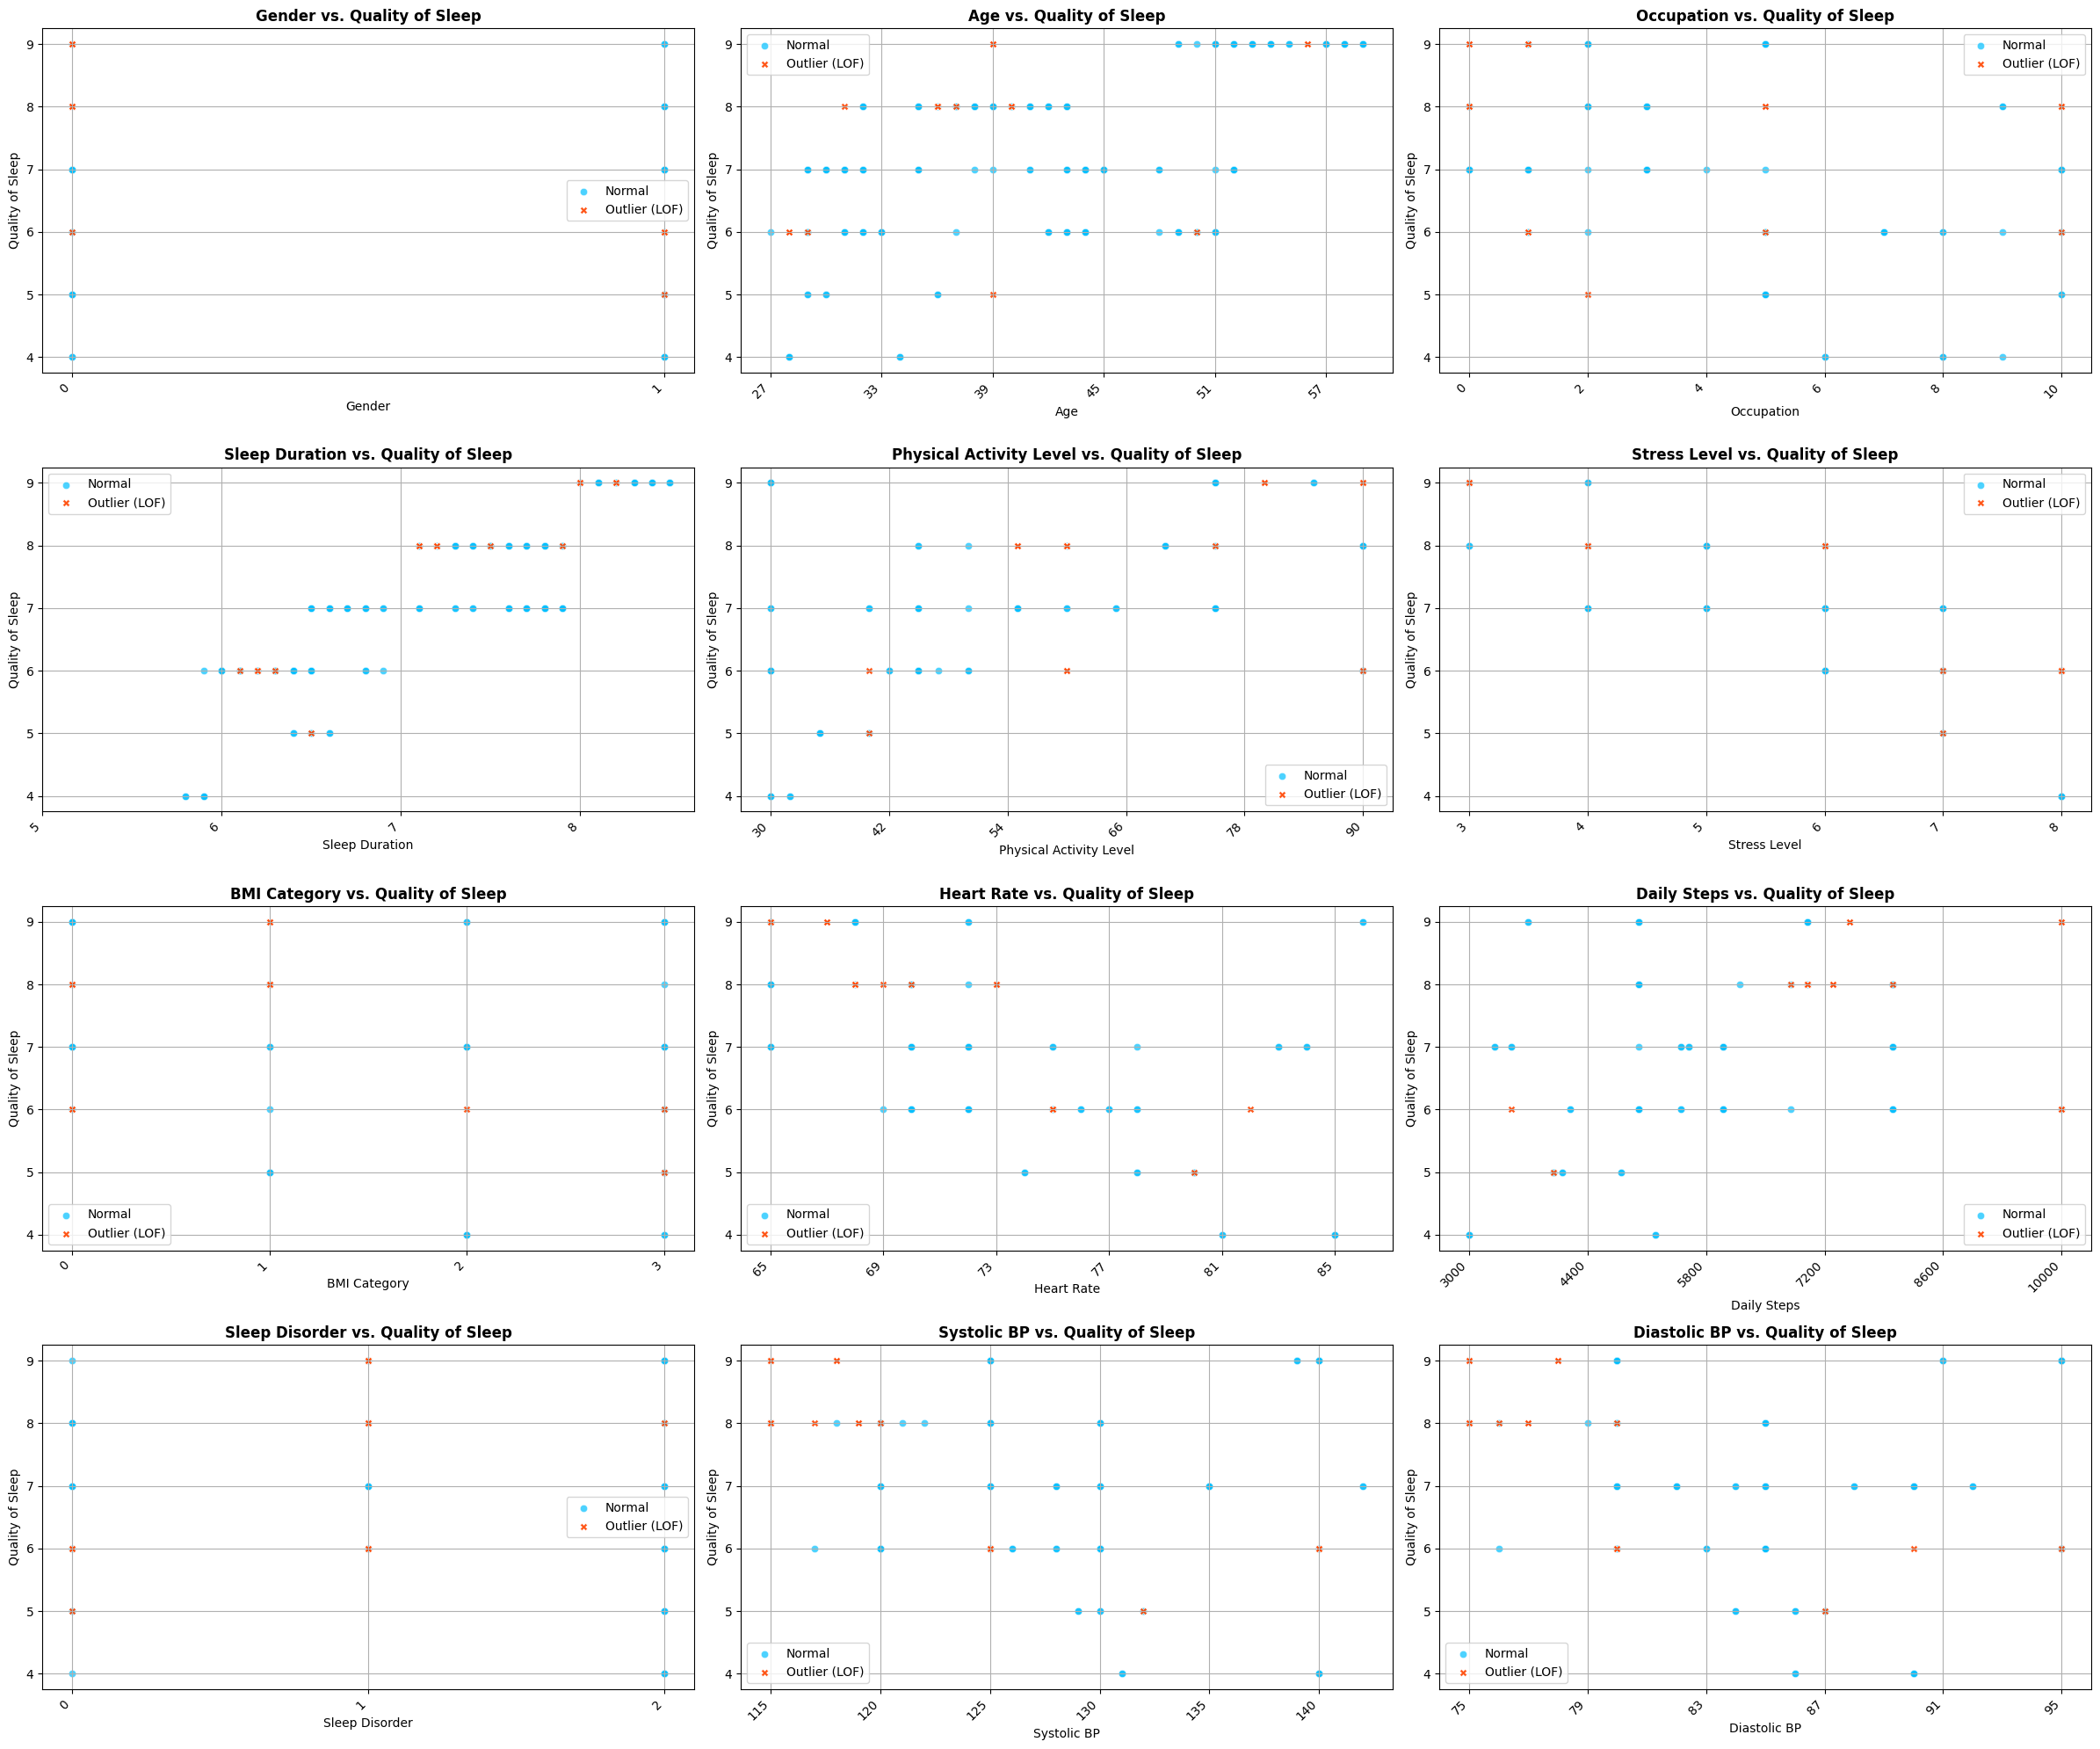

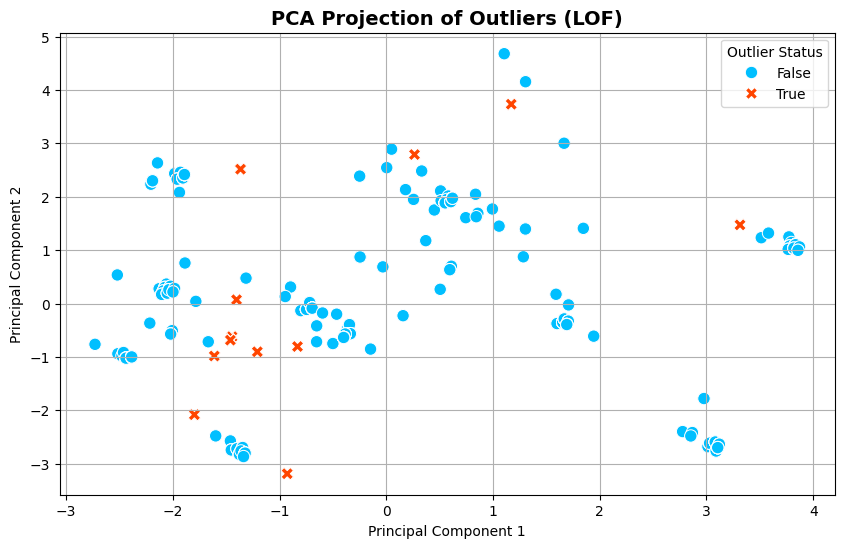


Agreement between LOF and Isolation Forest (proxy accuracy): 0.93


In [ ]:
#INSTALL REQUIRED PACKAGES
!pip install -q kaggle scikit-learn matplotlib seaborn numpy pandas

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score

#KAGGLE API SETUP
os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_credentials = {
  "username":"abhinavmj",
  "key":"af770db536ed4651eb100b699f67a234"
}

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)
os.chmod("/root/.kaggle/kaggle.json", 600)

#DOWNLOAD DATASET
!kaggle datasets download -d uom190346a/sleep-health-and-lifestyle-dataset -p /content --unzip

#LOAD AND PREPROCESS DATA
df = pd.read_csv("/content/Sleep_health_and_lifestyle_dataset.csv")
df = df.drop(columns=['Person ID'])
df[['Systolic BP', 'Diastolic BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df = df.drop(columns=['Blood Pressure'])

df['Sleep Disorder'] = df['Sleep Disorder'].fillna("None")

label_encoders = {}
for col in ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

#OUTLIER DETECTION (LOF)
features = df.drop(columns=['Quality of Sleep']).select_dtypes(include=np.number)
X_scaled = StandardScaler().fit_transform(features)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
outlier_labels = lof.fit_predict(X_scaled)
df['Outlier'] = outlier_labels == -1
print(f"\nDetected outliers: {df['Outlier'].sum()}")

#PLOT
plot_features = [col for col in df.columns if col not in ['Quality of Sleep', 'Outlier']]

plt.figure(figsize=(24, 20))
for i, feature in enumerate(plot_features, 1):
    plt.subplot(4, 3, i)

    sns.scatterplot(
        data=df[~df['Outlier']],
        x=feature,
        y='Quality of Sleep',
        color='deepskyblue',
        alpha=0.7,
        label='Normal'
    )
    sns.scatterplot(
        data=df[df['Outlier']],
        x=feature,
        y='Quality of Sleep',
        color='orangered',
        alpha=0.9,
        label='Outlier (LOF)',
        marker='X'
    )

    x_min = int(df[feature].min())
    x_max = int(df[feature].max())
    step = max(1, (x_max - x_min) // 5)

    plt.xticks(np.arange(x_min, x_max + 1, step), rotation=45, ha='right')
    plt.title(f"{feature} vs. Quality of Sleep", fontweight='bold')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


#PCA VISUALIZATION
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=df['Outlier'],
    palette={False: 'deepskyblue', True: 'orangered'},
    style=df['Outlier'],
    markers={False: 'o', True: 'X'},
    s=80
)
plt.title('PCA Projection of Outliers (LOF)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title="Outlier Status")
plt.grid(True)
plt.show()

#ACCURACY SCORE WITH ISOLATION FOREST
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_preds = iso_forest.fit_predict(X_scaled)

iso_outliers = iso_preds == -1

accuracy = accuracy_score(df['Outlier'], iso_outliers)
print(f"\nAgreement between LOF and Isolation Forest (proxy accuracy): {accuracy:.2f}")


In [ ]:
# Eigenvalues and Eigenvectors from PCA
eigenvalues = pca.explained_variance_
eigenvectors = pca.components_
print("\nEigenvalues (explained variance):")
for i, val in enumerate(eigenvalues):
    print(f"Principal Component {i+1}: {val:.4f}")
print("\nEigenvectors (Principal Axes):")
for i, vec in enumerate(eigenvectors):
    print(f"Principal Component {i+1}:")
    print(vec)
# Determine principal component (the one with the highest eigenvalue)
principal_index = np.argmax(eigenvalues)
print(f"\nPrincipal Component {principal_index+1} explains the most variance.")


Eigenvalues (explained variance):
Principal Component 1: 3.9314
Principal Component 2: 2.8373

Eigenvectors (Principal Axes):
Principal Component 1:
[-0.21231963  0.33126419  0.3101506  -0.1185509   0.18013467  0.05248264
  0.43404891  0.15030558  0.12205057  0.16247407  0.46408667  0.4817395 ]
Principal Component 2:
[ 0.30436262 -0.35675902  0.09039792 -0.50982364 -0.11900273  0.53986128
  0.09843481  0.41876744 -0.03549432 -0.14018133  0.02036929 -0.00121226]

Principal Component 1 explains the most variance.


In [ ]:
# Get feature names used in PCA
pca_features = features.columns.tolist()
# Eigenvectors
eigenvectors = pca.components_
# Number of top features to display per PC
top_n = 5
print("\n🔍 Top Dominant Features per Principal Component:\n")
for i, component in enumerate(eigenvectors):
    sorted_idx = np.argsort(np.abs(component))[::-1][:top_n]
    print(f"Principal Component {i+1} (explains {pca.explained_variance_[i]:.2f} variance):")
    for idx in sorted_idx:
        feat_name = pca_features[idx]
        weight = component[idx]
        print(f"  {feat_name:<25} -> weight: {weight:.4f}")
    print()


🔍 Top Dominant Features per Principal Component:

Principal Component 1 (explains 3.93 variance):
  Diastolic BP              -> weight: 0.4817
  Systolic BP               -> weight: 0.4641
  BMI Category              -> weight: 0.4340
  Age                       -> weight: 0.3313
  Occupation                -> weight: 0.3102

Principal Component 2 (explains 2.84 variance):
  Stress Level              -> weight: 0.5399
  Sleep Duration            -> weight: -0.5098
  Heart Rate                -> weight: 0.4188
  Age                       -> weight: -0.3568
  Gender                    -> weight: 0.3044



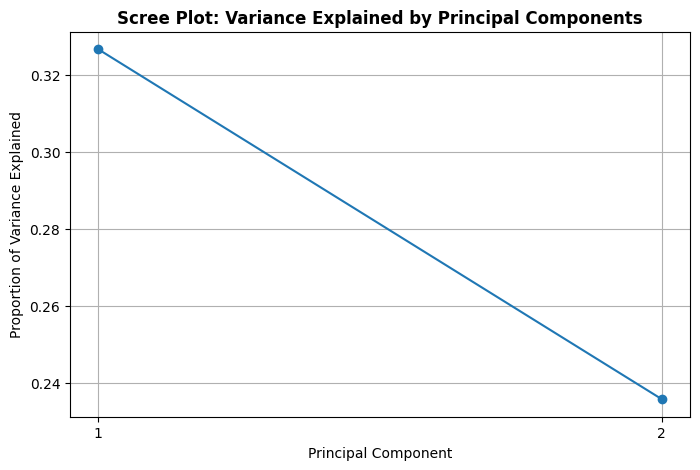

In [ ]:
# Scree Plot
plt.figure(figsize=(8, 5))
explained_variance_ratio = pca.explained_variance_ratio_
plt.plot(np.arange(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='-')
plt.title('Scree Plot: Variance Explained by Principal Components', fontweight='bold')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.xticks(np.arange(1, len(explained_variance_ratio) + 1))
plt.grid(True)
plt.show()
